# DAY2 특징 제거와 MAPE 학습 비교

목적: 도메인 근거로 세운 특징 제거 가설을 검토하고, MAPE에 맞춘 학습의 효과와 부작용을 비교한다.

Batch1 학습 28개·Hold-out 8개와 기존 CV 5개 폴드 유지. 전체 36개 재학습은 하지 않는다. 이번 후보는 Batch1 CV로 선택하고, 이전에 본 Hold-out·Batch2의 후속 평가로 구분한다. 원본과 이전 모델 결과를 보존한다.

**보고서 연결:** 이 노트북은 해당 실험 단계의 실행 기록이다. 기존 셀 분리와 프로토콜 분리 결과를 함께 해석한 전체 결론은 [DAY2 보고서](../outputs/day2/DAY2_REPORT.md)에 있다.


In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.day2_ablation import main
# 결과가 있으면 학습/평가를 반복하지 않는다.
main()
OUT = ROOT / "outputs/day2/ablation_loss"
result = json.loads((OUT / "results.json").read_text())
comparison = pd.read_csv(OUT / "model_comparison.csv")
print("seed:", result["seed"], " / CV 후보:", result["n_candidates"])
print("현재 CV 선택:", result["overall_cv_winner"])
display(pd.DataFrame([result["versions"]]))

Completed run exists; use saved results, no repeated fitting or evaluation.
seed: 42  / CV 후보: 35
현재 CV 선택: mape_raw_full_a0.01


,python,numpy,pandas,sklearn,joblib
0,3.11.15,2.4.6,3.0.6,1.9.1,1.6.0


## 1. 분할과 누수 방지

같은 셀은 학습과 검증에 중복되지 않는다. 입력은 100사이클 이내이며 전처리는 각 CV 학습 폴드에서만 fit한다. 수명은 MAPE 가중치를 계산하는 학습 손실에만 사용하고 입력 X에 넣지 않는다.

In [2]:
split = pd.read_csv(ROOT / "outputs/day2/feature_experiments/split_manifest.csv")
display(split.groupby(["batch", "role"]).size().rename("cells").to_frame())
print("이번 평가: 학습28, Hold-out8, Batch2 유효39 / Batch3 미평가")

cells
batch  role                    
Batch1 development           28
       excluded              10
       holdout                8
Batch2 excluded               8
       external_reserved     39
Batch3 excluded               2
       external_reserved     44

이번 평가: 학습28, Hold-out8, Batch2 유효39 / Batch3 미평가


## 2. 도메인 가설

| 특징 | 가설 |
|---|---|
| 초기 용량 | 셀 초기 상태·측정 조건도 반영하므로 배치 차이를 학습할 수 있다. |
| 용량 변화율 | 초기 용량 증가가 이후 열화와 공존할 수 있어 수명과의 관계가 배치마다 달라질 수 있다. |
| 초기 감소 속도 | 초기 변화가 작으면 일시적 변동에 민감하고 변화율과 정보가 겹칠 수 있다. |
| ΔQ 최솟값 | 곡선의 국소 변화와 잡음에 민감하고 분산과 중복될 수 있다. |

원논문은 초기 총 용량보다 전압 곡선 변화의 예측력을 강조한다. 그러나 ΔQ 통계값 하나가 특정 열화 기전을 증명하지는 않는다. [원논문](https://www.nature.com/articles/s41560-019-0356-8)

아래는 인과 확정이 아닌 모델 비교 가설이다. 이전 Batch2 진단의 영향을 받은 후속 탐색이다.

In [3]:
ablation = pd.read_csv(OUT / "ablation_comparison.csv")
display(ablation[["title", "cv_mape_pct", "cv_change_vs_full_pp", "oof_mae", "oof_rmse"]].round(4))

,title,cv_mape_pct,cv_change_vs_full_pp,oof_mae,oof_rmse
0,ΔQ 최솟값 제거,7.6864,-0.0116,61.7461,77.9864
1,용량 변화율 제거,7.6935,-0.0044,61.7484,78.3722
2,초기 감소 속도 제거,7.6967,-0.0013,61.6423,78.2200
3,5개 특징 유지,7.6979,0.0000,61.6697,78.2922
4,초기 용량 제거,9.8054,2.1075,77.8498,96.6039


## 3. 특징 제거 결과 해석

Target=log10 수명, Ridge alpha=1을 고정하고 특징 하나씩만 제거했다.

- 초기 용량 제거: CV 7.698% → 9.805%로 악화. Batch1 내부에서는 유용하다.
- 나머지 제거: 개선 폭 0.012%p 이내. 확실한 성능 개선보다 단순화 후보로 해석한다.
- 모든 제거 모델을 Batch2에 적용하지 않았으므로 초기 용량 제거가 배치 간 성능을 개선하는지는 미확인이다.
- 최소 CV의 ΔQ 최솟값 제거 모델도 후속 Batch2 오차는 커졌다. 내부 개선이 외부 개선을 보장하지 않는다.

## 4. MAPE에 맞춘 학습과 대조군

두 모델 모두 원 수명 Target과 QuantileRegressor(quantile=0.5)를 사용한다. 전처리·특징·L1 alpha를 맞추고 가중치만 비교한다.

```python
# 해당 학습 폴드의 y_train만 사용
weights = 1.0 / y_train
weights /= weights.mean()
model.fit(X_train, y_train, model__sample_weight=weights)
```

가중 절대오차는 MAPE에 비례한다. alpha>0이면 L1 규제가 추가된다. 로그 수명 오차에 가중치를 곱하지 않는다. 단수명 오차의 영향이 커지므로 MAE·RMSE와 과소 예측도 확인한다.

[MAPE 회귀 연구](https://arxiv.org/abs/1605.02541), [모델 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.QuantileRegressor.html)

In [4]:
paired = pd.read_csv(OUT / "paired_loss_comparison.csv")
display(paired.sort_values(["removal", "alpha"])[[
    "removal", "alpha", "cv_mape_pct_mae", "cv_mape_pct_mape",
    "cv_weighting_change_pp", "oof_mae_change", "oof_rmse_change"
]].round(4))
print("학습 가중치 최대/최소 비율:", round(result["weight_max_min_ratio"], 3))

,removal,alpha,cv_mape_pct_mae,cv_mape_pct_mape,cv_weighting_change_pp,oof_mae_change,oof_rmse_change
1,delta_Q_min,0.00,7.7768,7.5086,-0.2682,-0.5146,-1.6457
0,delta_Q_min,0.01,7.1332,7.1161,-0.0170,0.0315,0.3703
9,delta_Q_min,0.10,9.1732,8.9266,-0.2466,-2.1302,-3.0611
10,early_drop_per100,0.00,9.2143,8.8416,-0.3727,-2.9156,-2.3214
4,early_drop_per100,0.01,8.4205,7.1077,-1.3129,-7.8102,-6.3008
8,early_drop_per100,0.10,8.9981,8.4383,-0.5597,-2.2403,0.1918
2,none,0.00,8.3763,7.1643,-1.2120,-10.2780,-6.0234
3,none,0.01,8.4205,7.1077,-1.3129,-7.8102,-6.3008
6,none,0.10,8.9981,8.4369,-0.5611,-2.2350,0.2736
11,qd_fraction_change,0.00,9.3683,8.8727,-0.4956,-3.6079,-3.0408


학습 가중치 최대/최소 비율: 2.011


15개 동일 조건 짝 모두 가중 모델의 CV MAPE가 낮았다. 전체 특징·alpha=0.01은 8.421% → 7.108%로 개선했지만, ΔQ 최솟값을 제외한 짝은 7.133% → 7.116%로 차이가 작았다. MAPE 학습의 효과는 특징 구성에 따라 달라진다. Ridge와 비교하면 Target·규제도 달라지므로 그 차이를 모두 가중치 효과라고 해석하지 않는다.

In [5]:
display(comparison.head(10)[["candidate", "cv_mape_pct", "cv_std_pp", "oof_mae", "oof_rmse"]].round(4))
print("CV 계열 대표:", result["family_cv_winners"])
print("계열 대표와 전체 최저 후보는 Hold-out/Batch2 평가 전에 고정")

,candidate,cv_mape_pct,cv_std_pp,oof_mae,oof_rmse
0,mape_raw_full_a0.01,7.1077,0.2305,59.2438,82.1815
1,mape_raw_minus_early_drop_per100_a0.01,7.1077,0.2305,59.2438,82.1815
2,mape_raw_minus_delta_Q_min_a0.01,7.1161,0.5171,58.2170,76.8588
3,mae_raw_minus_delta_Q_min_a0.01,7.1332,0.5158,58.1856,76.4885
4,mape_raw_minus_qd_fraction_change_a0.01,7.1447,0.2626,59.5719,82.7819
5,mape_raw_full_a0,7.1643,2.7824,58.5076,86.4834
6,mape_raw_minus_delta_Q_min_a0,7.5086,1.1766,59.9939,75.9174
7,ridge_minus_delta_Q_min,7.6864,1.1696,61.7461,77.9864
8,ridge_minus_qd_fraction_change,7.6935,0.8325,61.7484,78.3722
9,ridge_minus_early_drop_per100,7.6967,0.8625,61.6423,78.2200


CV 계열 대표: {'ridge_log': 'ridge_minus_delta_Q_min', 'mae_raw': 'mae_raw_minus_delta_Q_min_a0.01', 'mape_raw': 'mape_raw_full_a0.01'}
계열 대표와 전체 최저 후보는 Hold-out/Batch2 평가 전에 고정


## 5. 고정 모델 후속 평가

세 계열 대표를 CV로 고정한 뒤 학습 28개에만 fit했다. 같은 모델을 Hold-out과 Batch2에 적용하며, 외부 점수로 다시 선택하지 않는다.

,family,candidate,evaluation,mape_pct,mae,rmse,mean_prediction_minus_actual,underprediction_pct
0,ridge_log,ridge_minus_delta_Q_min,Valid (Batch 1 Hold-out),4.181,33.357,39.755,-1.104,37.500
1,ridge_log,ridge_minus_delta_Q_min,Test (Batch 2),43.588,226.436,242.742,214.802,5.128
2,mae_raw,mae_raw_minus_delta_Q_min_a0.01,Valid (Batch 1 Hold-out),3.549,29.881,41.326,-11.715,62.500
3,mae_raw,mae_raw_minus_delta_Q_min_a0.01,Test (Batch 2),33.147,174.540,192.605,164.008,7.692
4,mape_raw,mape_raw_full_a0.01,Valid (Batch 1 Hold-out),4.410,39.891,58.486,-23.872,75.000
5,mape_raw,mape_raw_full_a0.01,Test (Batch 2),33.876,175.156,189.681,149.904,7.692


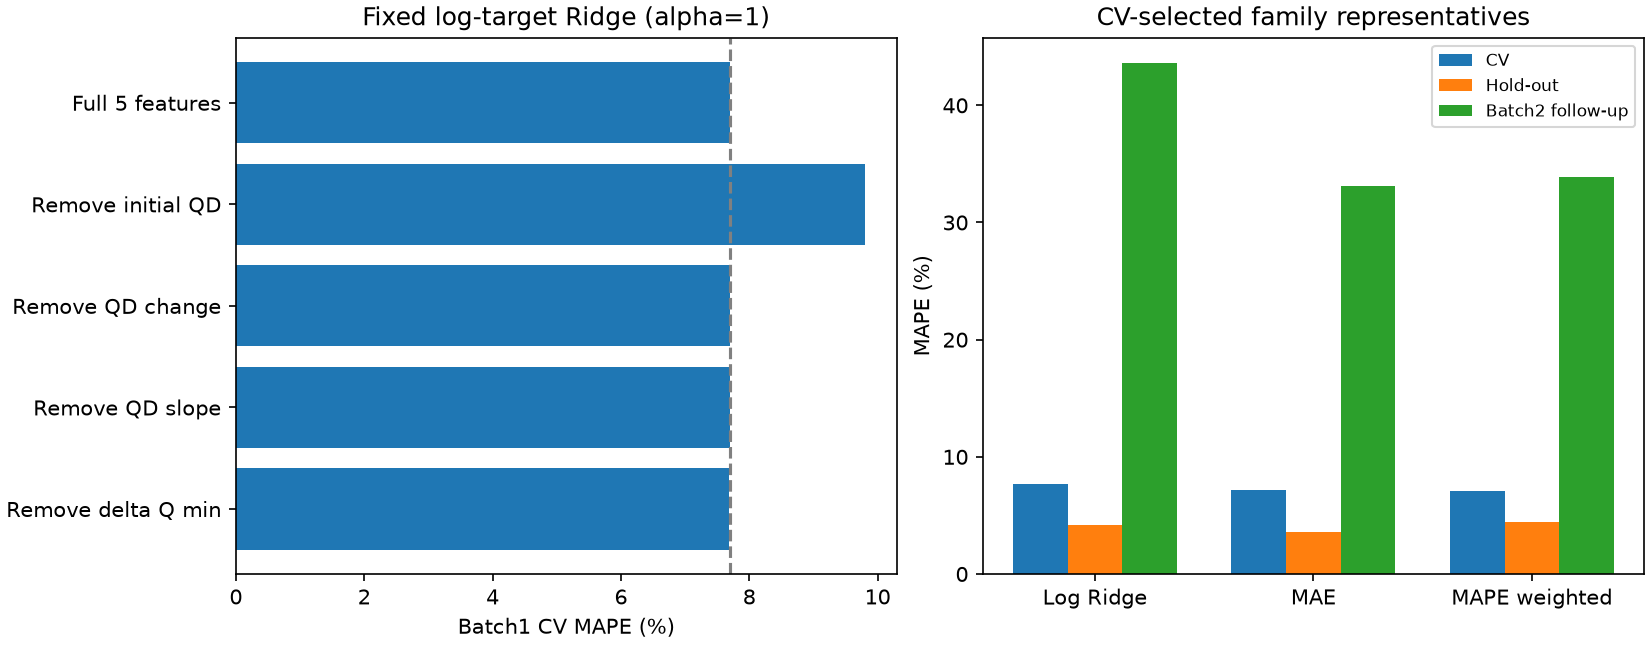

In [6]:
evaluation = pd.read_csv(OUT / "evaluation_metrics.csv")
display(evaluation[["family", "candidate", "evaluation", "mape_pct", "mae", "rmse", "mean_prediction_minus_actual", "underprediction_pct"]].round(3))
display(Image(filename=str(OUT / "comparison.png")))

현재 CV 선택은 MAPE 가중 모델이다. CV 7.108%, Hold-out 4.410%, Batch2 33.876%다.

기존 5개 특징 Ridge 대비 CV와 Batch2는 개선됐으나 Hold-out은 악화했다. 기존 단일 분산 모델의 Batch2 26.186%에는 못 미쳤다. 무가중 대표의 Batch2 점수가 더 낮아도 이를 보고 CV 선택을 바꾸지 않는다.

단수명 28개에서 평균 162.860사이클 과대 예측이 남았다. 장수명 3개는 평균 107.221사이클 과소 예측됐지만 소수 표본이고 모델도 달라 가중치만의 인과 효과로 단정하지 않는다.

In [7]:
display(pd.read_csv(OUT / "performance_reporting.csv").round(3))
display(pd.read_csv(OUT / "evaluation_segments.csv").round(3))

,구분,MAPE (%),비고
0,Train (Batch 1 CV),7.108,28개 학습 셀의 동일 5-fold 검증 평균
1,Valid (Batch 1 Hold-out),4.410,8개; 현재 선택에 사용하지 않음; 이전 평가 이력 있음
2,Test (Batch 2),33.876,39개; 고정 모델 후속 평가; 새 독립 Test 아님
3,Gap (Train-Valid),-2.697,Valid − CV; %p
4,Gap (Valid-Test),29.465,Test − Valid; %p
5,Gap (Target-Test),24.776,Test − 9.1; %p; 원논문과 조건 다른 참고 비교


,candidate,evaluation,life_band,n,mape_pct,mean_prediction_minus_actual
0,mae_raw_minus_delta_Q_min_a0.01,Test (Batch 2),<=500,28,34.963,155.678
1,mae_raw_minus_delta_Q_min_a0.01,Test (Batch 2),500-1000,8,35.178,256.883
2,mae_raw_minus_delta_Q_min_a0.01,Test (Batch 2),>1000,3,10.775,-5.913
3,mae_raw_minus_delta_Q_min_a0.01,Valid (Batch 1 Hold-out),500-1000,7,2.792,-0.069
4,mae_raw_minus_delta_Q_min_a0.01,Valid (Batch 1 Hold-out),>1000,1,8.846,-93.237
5,mape_raw_full_a0.01,Test (Batch 2),<=500,28,37.246,162.860
6,mape_raw_full_a0.01,Test (Batch 2),500-1000,8,28.841,200.981
7,mape_raw_full_a0.01,Test (Batch 2),>1000,3,15.849,-107.221
8,mape_raw_full_a0.01,Valid (Batch 1 Hold-out),500-1000,7,3.118,-7.027
9,mape_raw_full_a0.01,Valid (Batch 1 Hold-out),>1000,1,13.452,-141.786


## 6. 모델링 시사점

1. 초기 용량은 내부 예측에 유용하지만 배치 간 안정성은 별개다.
2. 특징 제거의 작은 CV 개선으로 외부 개선을 주장할 수 없다.
3. MAPE에 맞춘 학습은 누수가 아니며 후보로 비교할 수 있지만, 이번 결과에서 배치 일반화를 해결하지 못했다.
4. Batch1에 500 미만 셀이 없고 제공 수명은 종료 경계 레이블이라는 한계가 남는다.
5. 후보 선택은 Batch1 CV에 한정했지만 과거 외부 결과를 본 후 가설을 세웠으므로 후속 탐색으로 보고한다. 9.1%는 조건이 다른 원논문 참고 수치다.

전체 설명은 `outputs/day2/DAY2_REPORT.md`, 재현 코드는 `src/day2_ablation.py`에 있다. 이번 실험으로 전체 프로젝트의 최종 모델을 다시 확정하지 않는다.

## 이 실험 단계의 정리

기존 셀 분리 실험의 Batch1 CV 선택 후보는 MAPE 가중 회귀(alpha=0.01)로 유지한다. CV 7.11%, Hold-out 4.41%, Batch2 후속 평가 33.88%다. 이전 Batch2 최저 점수 모델로 사후 재선택하지 않는다.

초기 용량은 Batch1 내부에서 유용했지만 배치 간 안정성은 별개다. MAPE 학습은 내부 목표를 개선했으나 단수명 과대 예측을 해결하지 못했다. 목표 9.1% 미달과 반복 개발 이후 평가라는 한계를 함께 보고한다.

도메인 근거 → EDA → 가설 → 실험 결과 → 모델 선택 → 일반화 한계의 전체 연결은 `outputs/day2/DAY2_REPORT.md`에 정리했다. 기존 출력과 모델은 그대로 유지하고 추가 학습·평가를 종료했다.